# Plot Seasonal Accumulation

Plots 12-h snow and liquid precipitation equivalent (LPE) accumulation for the 2022/23 and 2023/24 cool seasons at Collins Alta (CLN), stratified by storm type for 75th percentile events: S/SWIVT, Frontal, NW Postfrontal. For each event below the 75th percentile threshold or not in one of storm types, the snow and LPE will be indicated. Cumulative seasonal totals are overlaid on each panel.

**Authors:** Ashley Evans, Michael Wasserstein  
**Date:** 20 June 2024

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [2]:
# Read in the dataset of all the 75th percentile events
ds_75 = pd.read_csv('Data/2022_2023_Events_75.csv').drop(columns = ['Unnamed: 0', 'Time (LST)' , '12 hr Snow (in.)',
                                                           '12 hr LPE (in.)', 'start_time_dt', 'end_time_dt', 'start_time_UTC',
                                                           'mid_time_UTC',])

# convert to datetime
ds_75['end_time_UTC'] = pd.to_datetime(ds_75['end_time_UTC'])

In [3]:
# Read in the datset for all precipitation during the 2023 and 2024 cool seasons
ds_full = pd.read_csv('Data/CLN_2022_2024_complete.csv').drop(columns = ['Unnamed: 0', 'Start Time (LST)', 'End Time (LST)',
                                                                               'Start Time (UTC)',])

# Rename column
ds_full = ds_full.rename(columns = {'End Time (UTC)' : 'end_time_UTC'})

# Convert to metric units
ds_full['12_hr_snow_cm'] = ds_full['12 hr Snow (in.)'] * 2.54
ds_full['12_hr_LPE_mm'] = ds_full['12 hr LPE (in.)'] * 25.4

# Drop unnecessary columns
ds_full = ds_full.drop(columns = ['12 hr Snow (in.)', '12 hr LPE (in.)'])

# Convert to datetime
ds_full['end_time_UTC'] = pd.to_datetime(ds_full['end_time_UTC'])


## Define Analysis Periods

Each tuple is a (start, end) UTC timestamp for a 12-h observing window. These were manually classified before analysis, following methods from [Wasserstein and Steenburgh (2024)](https://journals.ametsoc.org/view/journals/mwre/152/4/MWR-D-23-0206.1.xml).

In [6]:
# Frontal periods with data available at both sites
fr = [('2022-12-04 23:00:00', '2022-12-05 11:00:00'),
                      ('2022-12-27 23:00:00', '2022-12-28 11:00:00'),
                      ('2023-01-10 23:00:00', '2023-01-11 11:00:00'),
                      ('2023-02-05 11:00:00', '2023-02-05 23:00:00'),
                      ('2023-02-21 23:00:00', '2023-02-22 11:00:00'), 
                      ('2023-03-05 23:00:00', '2023-03-06 11:00:00'),
                      ('2023-03-10 23:00:00', '2023-03-11 11:00:00'),
                      ('2023-03-15 10:00:00', '2023-03-15 22:00:00'),
                      ('2023-03-24 10:00:00', '2023-03-24 22:00:00'),
                      ('2024-02-15 11:00:00', '2024-02-15 23:00:00'),
                      ('2024-02-26 23:00:00', '2024-02-27 11:00:00'),
                      ('2024-03-23 22:00:00', '2024-03-24 10:00:00')
                     ]

# Convert to datetime tuples
fr_dt = [(pd.to_datetime(start).tz_localize('UTC'), pd.to_datetime(end).tz_localize('UTC')) for start, end in fr]

# SIVT or SWIVT periods with data available at both sites
sivt = [('2022-12-01 23:00:00', '2022-12-02 11:00:00'),
                      ('2022-12-11 23:00:00', '2022-12-12 11:00:00'),
                      ('2022-12-31 23:00:00', '2023-01-01 11:00:00'),
                      ('2023-01-01 11:00:00', '2023-01-01 23:00:00'),
                      ('2023-01-09 23:00:00', '2023-01-10 11:00:00'),
                      ('2023-01-14 23:00:00', '2023-01-15 11:00:00'),
                      ('2023-03-14 22:00:00', '2023-03-15 10:00:00'),
                      ('2024-02-01 23:00:00', '2024-02-02 11:00:00'),
                      ('2024-02-05 11:00:00', '2024-02-05 23:00:00'),
                      ('2024-02-06 23:00:00', '2024-02-07 11:00:00'),
                      ('2024-02-19 23:00:00', '2024-02-20 11:00:00'),
                      ('2024-03-28 10:00:00', '2024-03-28 22:00:00'),
                      ('2024-03-30 22:00:00', '2024-03-31 10:00:00')
                     ]

# Convert to datetime tuples
sivt_dt = [(pd.to_datetime(start).tz_localize('UTC'), pd.to_datetime(end).tz_localize('UTC')) for start, end in sivt]

# NW Postfrontal periods with data available at both sites
pf = [('2022-11-28 23:00:00', '2022-11-29 11:00:00'), 
                      ('2022-12-12 23:00:00', '2022-12-13 11:00:00'),
                      ('2022-12-13 11:00:00', '2022-12-13 23:00:00'),
                      ('2022-12-13 23:00:00', '2022-12-14 11:00:00'),
                      ('2022-12-14 11:00:00', '2022-12-14 23:00:00'),
                      ('2022-12-15 11:00:00', '2022-12-15 23:00:00'),
                      ('2022-12-28 11:00:00', '2022-12-28 23:00:00'),
                      ('2022-12-28 23:00:00', '2022-12-29 11:00:00'),
                      ('2023-01-06 11:00:00', '2023-01-06 23:00:00'),  
                      ('2023-01-11 11:00:00', '2023-01-11 23:00:00'),
                      ('2023-01-24 23:00:00', '2023-01-25 11:00:00'),
                      ('2023-01-27 23:00:00', '2023-01-28 11:00:00'),
                      ('2023-01-28 11:00:00', '2023-01-28 23:00:00'),
                      ('2023-02-06 11:00:00', '2023-02-06 23:00:00'),
                      ('2023-03-24 22:00:00', '2023-03-25 10:00:00'), 
                      ('2023-03-27 10:00:00', '2023-03-27 22:00:00'),
                      ('2023-12-08 11:00:00', '2023-12-08 23:00:00'),
                      ('2023-12-08 23:00:00', '2023-12-09 11:00:00'),
                      ('2024-01-05 11:00:00', '2024-01-05 23:00:00'),
                      ('2024-01-07 11:00:00', '2024-01-07 23:00:00'),
                      ('2024-01-14 11:00:00', '2024-01-14 23:00:00'),
                      ('2024-02-02 23:00:00', '2024-02-03 11:00:00'),
                      ('2024-02-03 23:00:00', '2024-02-04 11:00:00'),
                      ('2024-02-09 11:00:00', '2024-02-09 23:00:00'),
                      ('2024-03-24 10:00:00', '2024-03-24 22:00:00'),
                      ('2024-04-06 10:00:00', '2024-04-06 22:00:00'),
                      ('2024-04-06 22:00:00', '2024-04-07 10:00:00'),
                      ('2024-04-15 22:00:00', '2024-04-16 10:00:00')
                     ]

# Convert to datetime tuples
pf_dt = [(pd.to_datetime(start).tz_localize('UTC'), pd.to_datetime(end).tz_localize('UTC')) for start, end in pf]


In [7]:
# Initalize an array in the precipitation dataset for the synoptic classifications
ds_full['Classification'] = np.zeros(len(ds_full))

In [9]:
# Convert to dataframe
pf_df = pd.DataFrame(pf_dt, columns = ['start_time_UTC', 'end_time_UTC'])
fr_df = pd.DataFrame(fr_dt, columns = ['start_time_UTC', 'end_time_UTC'])
sivt_df = pd.DataFrame(sivt_dt, columns = ['start_time_UTC', 'end_time_UTC'])

In [10]:
# Merge datasets for each classification with the full precip dataset
merged_df_sivt = pd.merge(ds_full, sivt_df, how = 'inner')
merged_df_sivt['Classification'] = 1

merged_df_fr = pd.merge(ds_full, fr_df, how = 'inner')
merged_df_fr['Classification'] = 6

merged_df_pf = pd.merge(ds_full, pf_df, how = 'inner')
merged_df_pf['Classification'] = 5

In [11]:
# Determine a datset for the NAs (75th percentile, but not in a classifciation or below 75th)
# First, concatenate the three exclusion datasets
combined_df = pd.concat([sivt_df, fr_df, pf_df]).drop_duplicates()

# Now do an anti-join: keep only rows in ds_full that are not in combined_df
ds_NA = pd.merge(ds_full, combined_df, how='left', indicator=True)
ds_NA = ds_NA[ds_NA['_merge'] == 'left_only'].drop(columns=['_merge', 'start_time_UTC'])

In [13]:
# Subset datsets based on the two cool seasons
def subset_ds(ds):

    ds_2023 = ds[ds['end_time_UTC'] < '2023-06-01 00:00'].reset_index(drop = True)
    ds_2024 = ds[ds['end_time_UTC'] > '2023-06-01 00:00'].reset_index(drop = True)
    
    return ds_2023, ds_2024

In [14]:
# # Merge, keeping all rows from ds_full and adding 'Classification' where available (if classified)
merged_df = ds_full.merge(ds_75[["end_time_UTC", "Classification"]], on="end_time_UTC", how="left")

# Seasonal subsets
merged_df_2023 = merged_df[merged_df['end_time_UTC'] < '2023-06-01 00:00'].reset_index(drop = True)
merged_df_2024 = merged_df[merged_df['end_time_UTC'] > '2023-06-01 00:00'].reset_index(drop = True)

In [15]:
# Generate the datasets for each year and classification
merged_df_2023_SW, merged_df_2024_SW = subset_ds(merged_df_sivt)
merged_df_2023_FR, merged_df_2024_FR = subset_ds(merged_df_fr)
merged_df_2023_PF, merged_df_2024_PF = subset_ds(merged_df_pf)
merged_df_2023_NA, merged_df_2024_NA = subset_ds(ds_NA)

In [16]:
# Stuff for plotting
fs = 30
fs_ticks = 25
lw = 4

# colors for the classifications
c_SW = 'orangered'
c_FR = 'dodgerblue'
c_PF = 'magenta'
c_other = 'gainsboro'
c_cum = 'black'

# For legend
handles = [
    Line2D([0], [0], color=c_other, lw=lw, label='Other'),
    Line2D([0], [0], color=c_SW, lw=lw, label='S/SWIVT'),
    Line2D([0], [0], color=c_FR, lw=lw, label='Frontal'),
    Line2D([0], [0], color=c_PF, lw=lw, label='NW Postfrontal'),
    Line2D([0], [0], color=c_cum, lw=lw, label='Cumulative'),
]



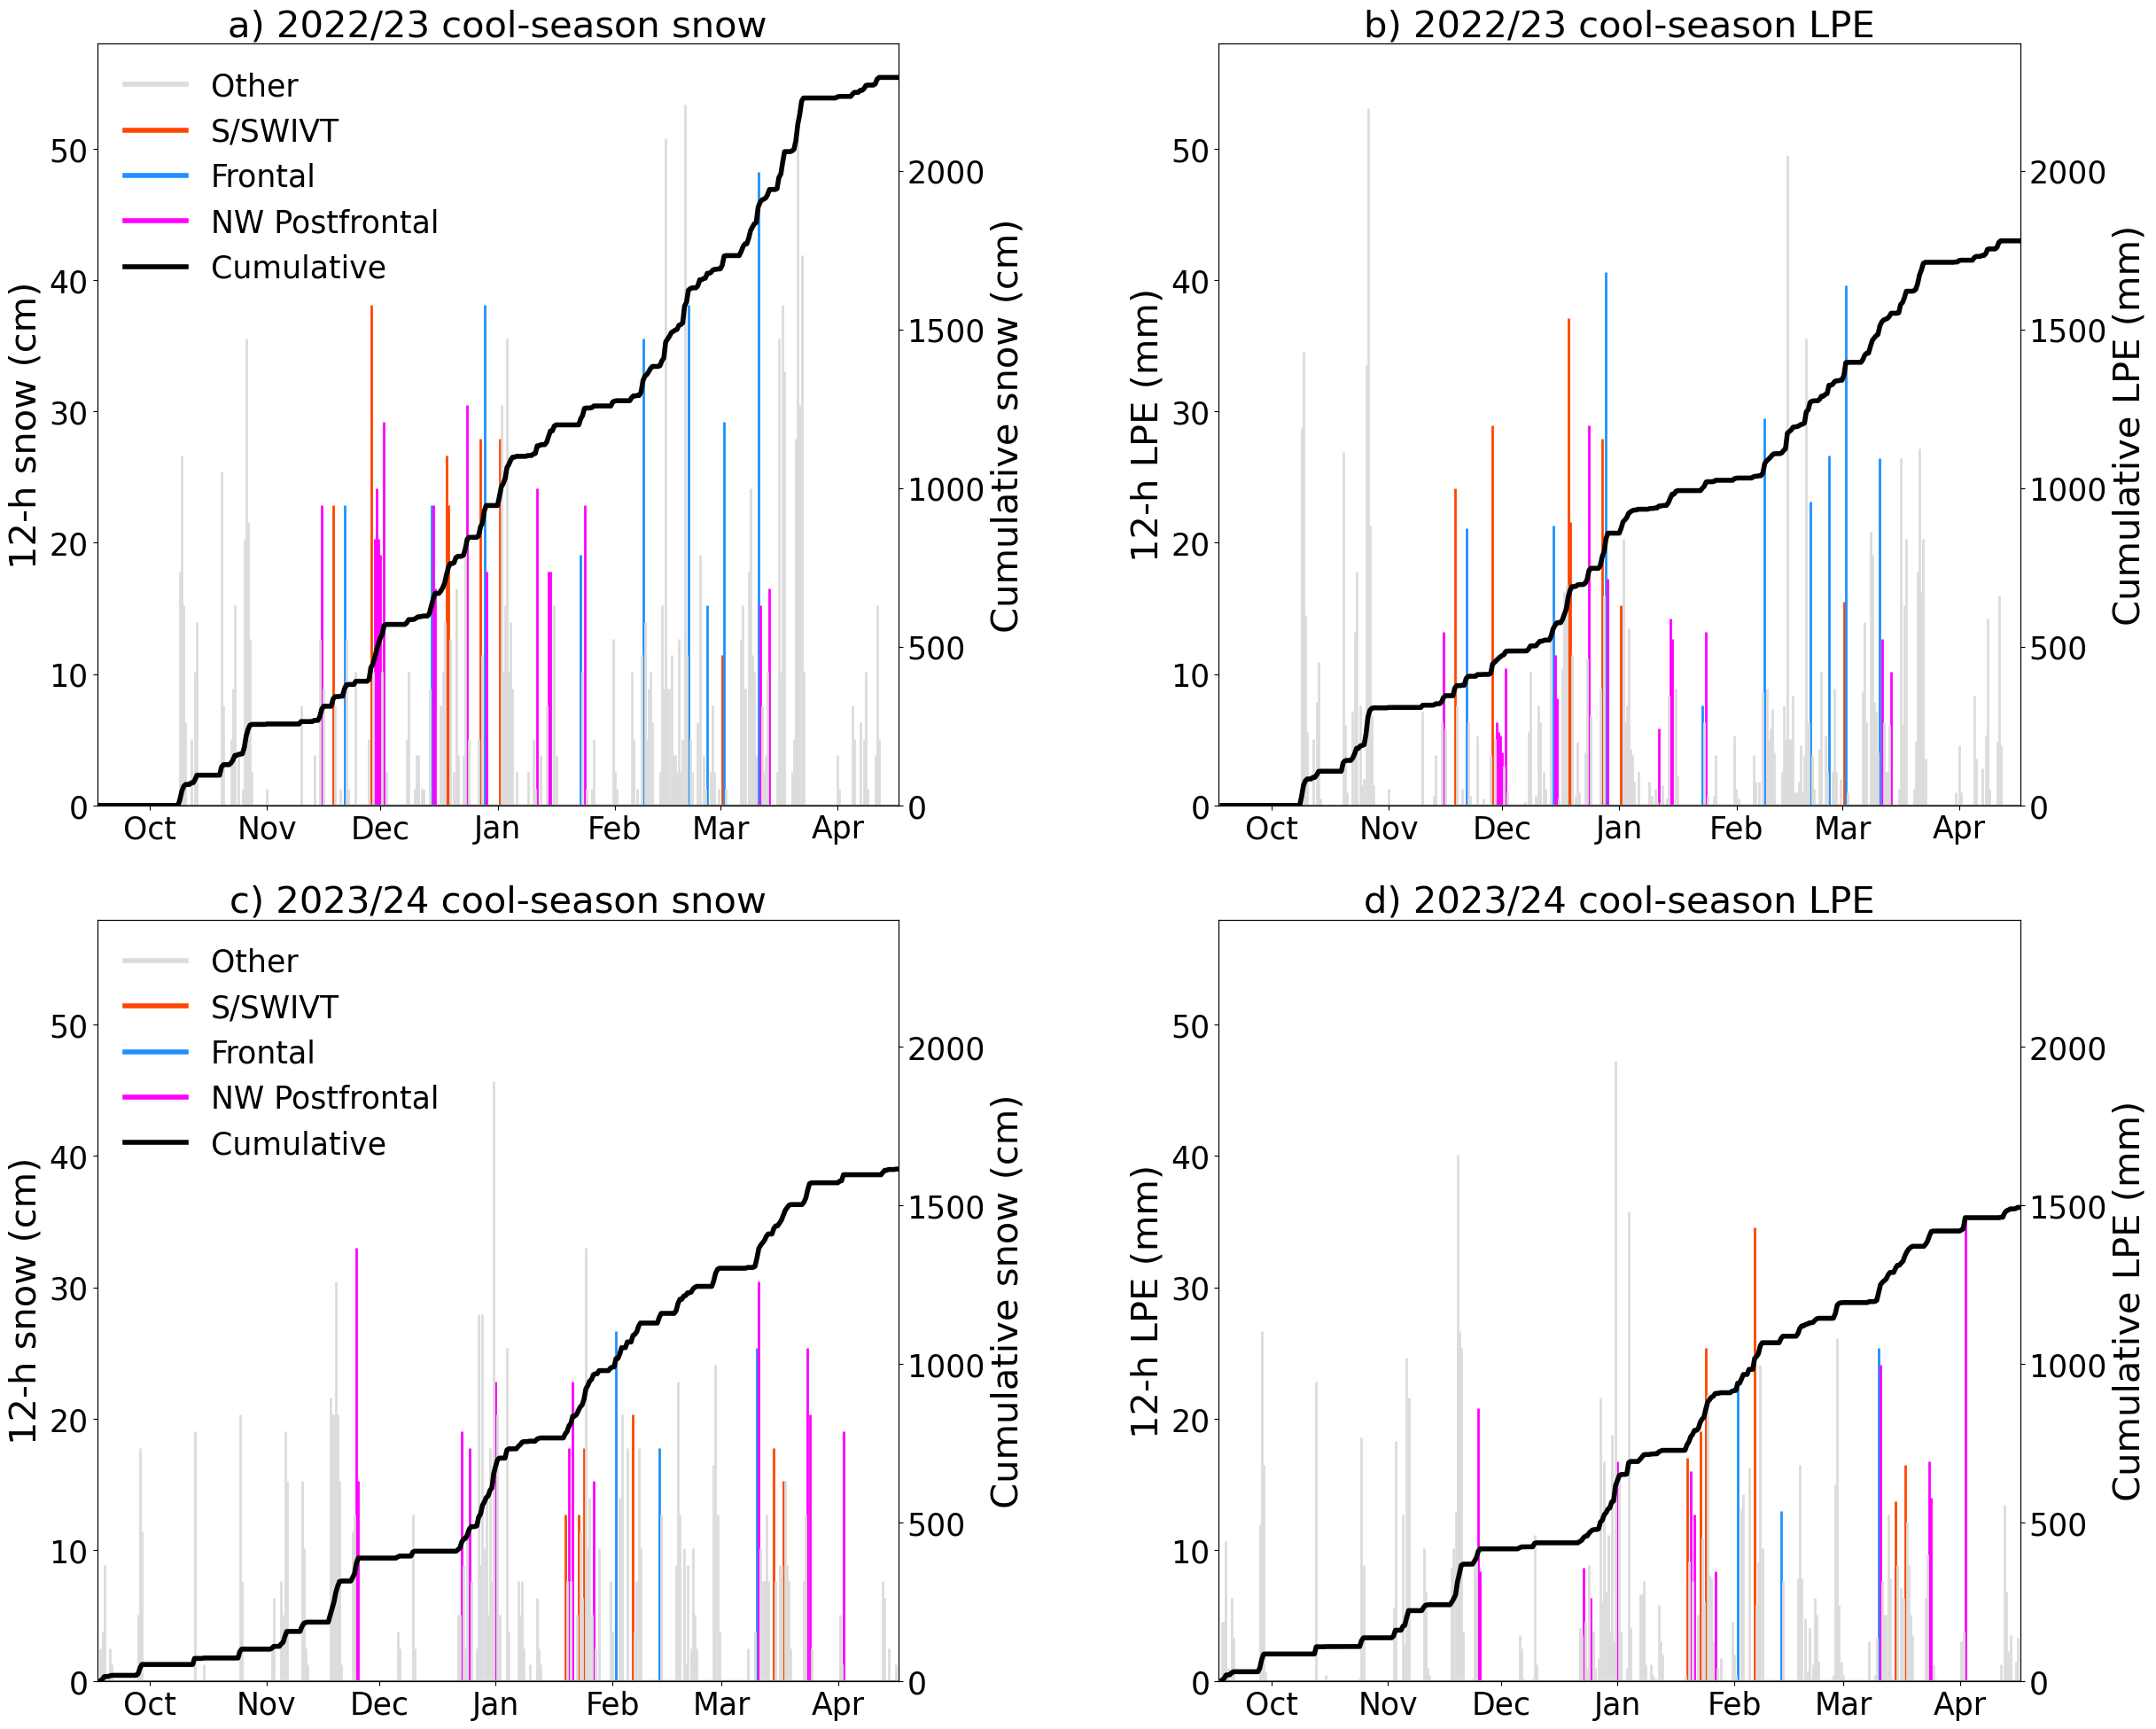

In [17]:
# Generate figure and axes
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(28, 24), facecolor='white', edgecolor='k')

################################################################################
# ax1 — 2022/23 Snow
################################################################################
xticks = pd.date_range('2022-10-1 00:00', '2023-4-1 00:00', freq='MS') + pd.DateOffset(days=14)
xtick_labels = xticks.strftime('%b')

# Plot stem for each event
SW_stem = ax1.stem(merged_df_2023_SW['end_time_UTC'], merged_df_2023_SW['12_hr_snow_cm'], linefmt=(c_SW, '-'), markerfmt='None', basefmt='gray')
FR_stem = ax1.stem(merged_df_2023_FR['end_time_UTC'], merged_df_2023_FR['12_hr_snow_cm'], linefmt=(c_FR, '-'), markerfmt='None', basefmt='gray')
PF_stem = ax1.stem(merged_df_2023_PF['end_time_UTC'], merged_df_2023_PF['12_hr_snow_cm'], linefmt=(c_PF, '-'), markerfmt='None', basefmt='gray')
NA_stem = ax1.stem(merged_df_2023_NA['end_time_UTC'], merged_df_2023_NA['12_hr_snow_cm'], linefmt=(c_other, '-'), markerfmt='None', basefmt='gray')

# Plot settings
for stem, zorder in zip([SW_stem, FR_stem, PF_stem], [2, 2, 2]):
    stem[0].set_zorder(zorder)
NA_stem[0].set_zorder(1)

for stem in [SW_stem, FR_stem, PF_stem, NA_stem]:
    stem[1].set_linewidth(2)

ax1.set_ylim(0, 58)
ax1.set_xlim(pd.to_datetime('2022-10-1 00:00'), pd.to_datetime('2023-4-30 23:59'))
ax1.set_ylabel('12-h snow (cm)', fontsize=fs)
ax1.set_yticks(np.arange(0, 51, 10), labels=np.arange(0, 51, 10), fontsize=fs_ticks)
ax1.set_xticks(xticks, labels=xtick_labels, fontsize=fs_ticks)
ax1.set_title('a) 2022/23 cool-season snow', fontsize=fs)
ax1.legend(handles=handles, frameon=False, fontsize=fs_ticks, loc='best', ncol=1)

# Add cumulative line
ax1_ = ax1.twinx()
ax1_.plot(merged_df_2023['end_time_UTC'], np.cumsum(merged_df_2023['12_hr_snow_cm']), color=c_cum, linewidth=lw, zorder=3)
ax1_.set_ylim(0, 2400)
ax1_.set_ylabel('Cumulative snow (cm)', fontsize=fs)
ax1_.set_yticks(np.arange(0, 2005, 500), labels=np.arange(0, 2005, 500), fontsize=fs_ticks)

################################################################################
# ax2 — 2022/23 LPE
################################################################################
# Plot stem for each event
SW_stem = ax2.stem(merged_df_2023_SW['end_time_UTC'], merged_df_2023_SW['12_hr_LPE_mm'], linefmt=(c_SW, '-'), markerfmt='None', basefmt='gray')
FR_stem = ax2.stem(merged_df_2023_FR['end_time_UTC'], merged_df_2023_FR['12_hr_LPE_mm'], linefmt=(c_FR, '-'), markerfmt='None', basefmt='gray')
PF_stem = ax2.stem(merged_df_2023_PF['end_time_UTC'], merged_df_2023_PF['12_hr_LPE_mm'], linefmt=(c_PF, '-'), markerfmt='None', basefmt='gray')
NA_stem = ax2.stem(merged_df_2023_NA['end_time_UTC'], merged_df_2023_NA['12_hr_LPE_mm'], linefmt=(c_other, '-'), markerfmt='None', basefmt='gray')

# Plot settings
for stem, zorder in zip([SW_stem, FR_stem, PF_stem], [2, 2, 2]):
    stem[0].set_zorder(zorder)
NA_stem[0].set_zorder(1)

for stem in [SW_stem, FR_stem, PF_stem, NA_stem]:
    stem[1].set_linewidth(2)

ax2.set_ylim(0, 58)
ax2.set_xlim(pd.to_datetime('2022-10-1 00:00'), pd.to_datetime('2023-4-30 23:59'))
ax2.set_ylabel('12-h LPE (mm)', fontsize=fs)
ax2.set_yticks(np.arange(0, 51, 10), labels=np.arange(0, 51, 10), fontsize=fs_ticks)
ax2.set_xticks(xticks, labels=xtick_labels, fontsize=fs_ticks)
ax2.set_title('b) 2022/23 cool-season LPE', fontsize=fs)

# Add cumulative line
ax2_ = ax2.twinx()
ax2_.plot(merged_df_2023['end_time_UTC'], np.cumsum(merged_df_2023['12_hr_LPE_mm']), color=c_cum, linewidth=lw, zorder=3)
ax2_.set_ylim(0, 2400)
ax2_.set_ylabel('Cumulative LPE (mm)', fontsize=fs)
ax2_.set_yticks(np.arange(0, 2005, 500), labels=np.arange(0, 2005, 500), fontsize=fs_ticks)

################################################################################
# ax3 — 2023/24 Snow
################################################################################
xticks = pd.date_range('2023-10-1 00:00', '2024-4-1 00:00', freq='MS') + pd.DateOffset(days=14)
xtick_labels = xticks.strftime('%b')

# Plot stem for each event
SW_stem = ax3.stem(merged_df_2024_SW['end_time_UTC'], merged_df_2024_SW['12_hr_snow_cm'], linefmt=(c_SW, '-'), markerfmt='None', basefmt='gray')
FR_stem = ax3.stem(merged_df_2024_FR['end_time_UTC'], merged_df_2024_FR['12_hr_snow_cm'], linefmt=(c_FR, '-'), markerfmt='None', basefmt='gray')
PF_stem = ax3.stem(merged_df_2024_PF['end_time_UTC'], merged_df_2024_PF['12_hr_snow_cm'], linefmt=(c_PF, '-'), markerfmt='None', basefmt='gray')
NA_stem = ax3.stem(merged_df_2024_NA['end_time_UTC'], merged_df_2024_NA['12_hr_snow_cm'], linefmt=(c_other, '-'), markerfmt='None', basefmt='gray')

# Plot settings
for stem, zorder in zip([SW_stem, FR_stem, PF_stem], [2, 2, 2]):
    stem[0].set_zorder(zorder)
NA_stem[0].set_zorder(1)

for stem in [SW_stem, FR_stem, PF_stem, NA_stem]:
    stem[1].set_linewidth(2)

ax3.set_ylim(0, 58)
ax3.set_xlim(pd.to_datetime('2023-10-1 00:00'), pd.to_datetime('2024-4-30 23:59'))
ax3.set_ylabel('12-h snow (cm)', fontsize=fs)
ax3.set_yticks(np.arange(0, 51, 10), labels=np.arange(0, 51, 10), fontsize=fs_ticks)
ax3.set_xticks(xticks, labels=xtick_labels, fontsize=fs_ticks)
ax3.set_title('c) 2023/24 cool-season snow', fontsize=fs)
ax3.legend(handles=handles, frameon=False, fontsize=fs_ticks, loc='upper left', ncol=1)

# Add cumulative line
ax3_ = ax3.twinx()
ax3_.plot(merged_df_2024['end_time_UTC'], np.cumsum(merged_df_2024['12_hr_snow_cm']), color=c_cum, linewidth=lw, zorder=3)
ax3_.set_ylim(0, 2400)
ax3_.set_ylabel('Cumulative snow (cm)', fontsize=fs)
ax3_.set_yticks(np.arange(0, 2005, 500), labels=np.arange(0, 2005, 500), fontsize=fs_ticks)

################################################################################
# ax4 — 2023/24 LPE
################################################################################
# Plot stem for each event
SW_stem = ax4.stem(merged_df_2024_SW['end_time_UTC'], merged_df_2024_SW['12_hr_LPE_mm'], linefmt=(c_SW, '-'), markerfmt='None', basefmt='gray')
FR_stem = ax4.stem(merged_df_2024_FR['end_time_UTC'], merged_df_2024_FR['12_hr_LPE_mm'], linefmt=(c_FR, '-'), markerfmt='None', basefmt='gray')
PF_stem = ax4.stem(merged_df_2024_PF['end_time_UTC'], merged_df_2024_PF['12_hr_LPE_mm'], linefmt=(c_PF, '-'), markerfmt='None', basefmt='gray')
NA_stem = ax4.stem(merged_df_2024_NA['end_time_UTC'], merged_df_2024_NA['12_hr_LPE_mm'], linefmt=(c_other, '-'), markerfmt='None', basefmt='gray')

# Plot settings
for stem, zorder in zip([SW_stem, FR_stem, PF_stem], [2, 2, 2]):
    stem[0].set_zorder(zorder)
NA_stem[0].set_zorder(1)

for stem in [SW_stem, FR_stem, PF_stem, NA_stem]:
    stem[1].set_linewidth(2)

ax4.set_ylim(0, 58)
ax4.set_xlim(pd.to_datetime('2023-10-1 00:00'), pd.to_datetime('2024-4-30 23:59'))
ax4.set_ylabel('12-h LPE (mm)', fontsize=fs)
ax4.set_yticks(np.arange(0, 51, 10), labels=np.arange(0, 51, 10), fontsize=fs_ticks)
ax4.set_xticks(xticks, labels=xtick_labels, fontsize=fs_ticks)
ax4.set_title('d) 2023/24 cool-season LPE', fontsize=fs)

# Add cumulative line
ax4_ = ax4.twinx()
ax4_.plot(merged_df_2024['end_time_UTC'], np.cumsum(merged_df_2024['12_hr_LPE_mm']), color=c_cum, linewidth=lw, zorder=3)
ax4_.set_ylim(0, 2400)
ax4_.set_ylabel('Cumulative LPE (mm)', fontsize=fs)
ax4_.set_yticks(np.arange(0, 2005, 500), labels=np.arange(0, 2005, 500), fontsize=fs_ticks)

# Save and show
plt.subplots_adjust(hspace=0.15, wspace=0.4)
plt.savefig('Fig/Precip_Snow_Accumulation_2022_2024.png', dpi=300, bbox_inches='tight')
plt.show()
